In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Привет, Дарья! Python работает 🎉")
print(f"Pandas version: {pd.__version__}")

Привет, Дарья! Python работает 🎉
Pandas version: 3.0.3


In [6]:
print(list(range(1, 21)))
print(f"Всего элементов: {len(range(1, 21))}")

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Всего элементов: 20


In [11]:
# Создаём простой датасет - представь что это результаты опроса студентов
# которые использовали AI-тьютора vs не использовали

data = {
    'student_id': range(1, 21),
    'ai_tutor': ['yes']*10 + ['no']*10,
    'confidence_score': [7, 8, 6, 9, 7, 8, 9, 6, 8, 7,   # группа с AI
                         5, 4, 6, 5, 3, 4, 5, 6, 4, 5],  # группа без AI
    'test_score': [78, 85, 72, 91, 80, 83, 88, 70, 84, 79,  # группа с AI
                   65, 58, 70, 63, 55, 60, 67, 71, 59, 62]  # группа без AI
}

df = pd.DataFrame(data)
print(df.head(21))
print(f"\nСредний test_score с AI: {df[df['ai_tutor']=='yes']['test_score'].mean():.1f}")
print(f"Средний test_score без AI: {df[df['ai_tutor']=='no']['test_score'].mean():.1f}")


    student_id ai_tutor  confidence_score  test_score
0            1      yes                 7          78
1            2      yes                 8          85
2            3      yes                 6          72
3            4      yes                 9          91
4            5      yes                 7          80
5            6      yes                 8          83
6            7      yes                 9          88
7            8      yes                 6          70
8            9      yes                 8          84
9           10      yes                 7          79
10          11       no                 5          65
11          12       no                 4          58
12          13       no                 6          70
13          14       no                 5          63
14          15       no                 3          55
15          16       no                 4          60
16          17       no                 5          67
17          18       no     

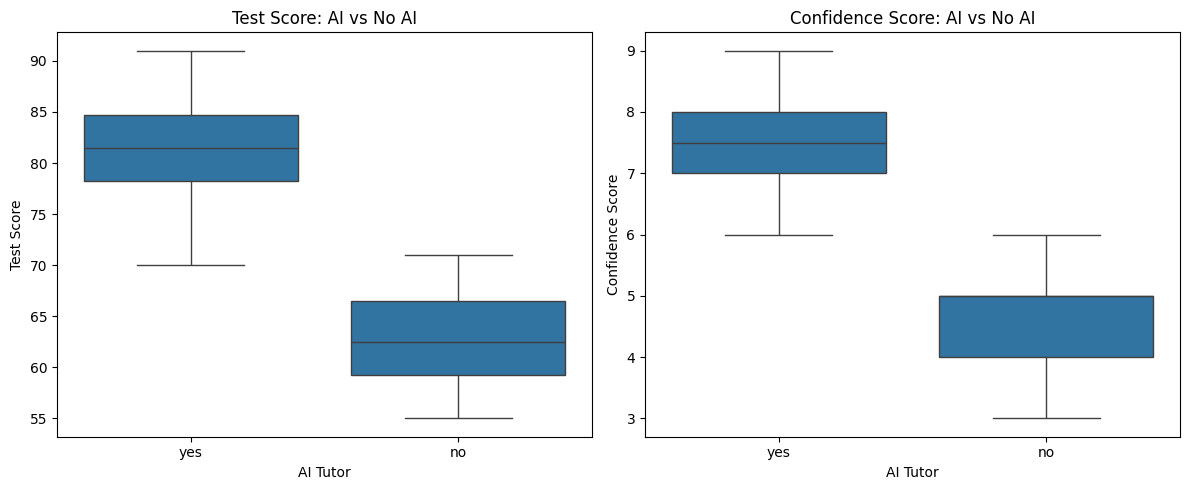

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: test_score по группам
sns.boxplot(data=df, x='ai_tutor', y='test_score', ax=ax1)
ax1.set_title('Test Score: AI vs No AI')
ax1.set_xlabel('AI Tutor')
ax1.set_ylabel('Test Score')

# График 2: confidence_score по группам
sns.boxplot(data=df, x='ai_tutor', y='confidence_score', ax=ax2)
ax2.set_title('Confidence Score: AI vs No AI')
ax2.set_xlabel('AI Tutor')
ax2.set_ylabel('Confidence Score')

plt.tight_layout()
plt.show()

In [17]:
from scipy import stats

ai_group = df[df['ai_tutor'] == 'yes']['test_score']
no_ai_group = df[df['ai_tutor'] == 'no']['test_score']

t_stat, p_value = stats.ttest_ind(ai_group, no_ai_group)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Разница статистически значима (p < 0.05)")
else:
    print("\n❌ Разница НЕ статистически значима")
    

T-statistic: 6.739
P-value: 0.0000

✅ Разница статистически значима (p < 0.05)
